In [27]:
import pandas as pd
df = pd.read_csv(r"c:\Users\Caio\OneDrive\Documentos\Projetos\Filmes e series netflix\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [29]:
df.shape

(8807, 12)

In [30]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')>

In [31]:
df.isnull().sum()
(df.isnull().mean() * 100).round(1) 

show_id          0.0
type             0.0
title            0.0
director        29.9
cast             9.4
country          9.4
date_added       0.1
release_year     0.0
rating           0.0
duration         0.0
listed_in        0.0
description      0.0
dtype: float64

In [32]:
df.duplicated().sum()
df["show_id"].duplicated().sum() # deveria ser 0, é a chave primária


np.int64(0)

In [33]:
df["release_year"].describe() # Gera estatísticas resumidas da coluna release_year: quantidade de valores, média, desvio-padrão, mínimo, máximo e quartis (25%, 50%, 75%).
df["type"].value_counts() # Conta quantas vezes cada valor único aparece na coluna type.
df["rating"].value_counts() # (classificação etária: TV-MA, PG-13, R etc.). Mostra quais classificações são mais comuns no catálogo, da mais para a menos frequente.

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

## Limpeza de Dados

In [34]:
#preencher com "não informado" os valores vazios

df["director"] = df["director"].fillna("Não informado")
df["cast"] = df["cast"].fillna("Não informado")
df["country"] = df["country"].fillna("Não informado")

In [35]:
#converter coluna string para o tipo data
#errors="coerce" transforma datas mal formatadas em NaT (nulo de data) em vez de quebrar o script

df["date_added"] = pd.to_datetime(df["date_added"].str.strip(),errors="coerce")

In [36]:
#duration mistura minuto (filme) com temporada (série) na mesma coluna, 
# então separei em duas colunas numéricas — uma pra cada caso. Agora dá pra calcular 
# média de duração e de temporadas sem misturar as duas coisas.

df["duracao_minutos"] = df.loc[df["type"] == "Movie",
"duration"].str.replace(" min", "").astype(float)
df["temporadas"] = df.loc[df["type"] == "TV Show",
"duration"].str.replace(" Season(s)?", "", regex=True).astype(float)

In [37]:
#country e listed_in têm vários valores na mesma célula, então "explodi" essas colunas pra contar cada país/gênero separado, em vez de contar a combinação toda como uma categoria só.

paises = df.assign(country=df["country"].str.split(",")).explode("country")

## Análise Exploratória com Perguntas de Negócio

In [38]:
df["type"].value_counts()
df["type"].value_counts(normalize=True) * 100

#Responde: a composição do catálogo é maioriafilme ou série?



type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

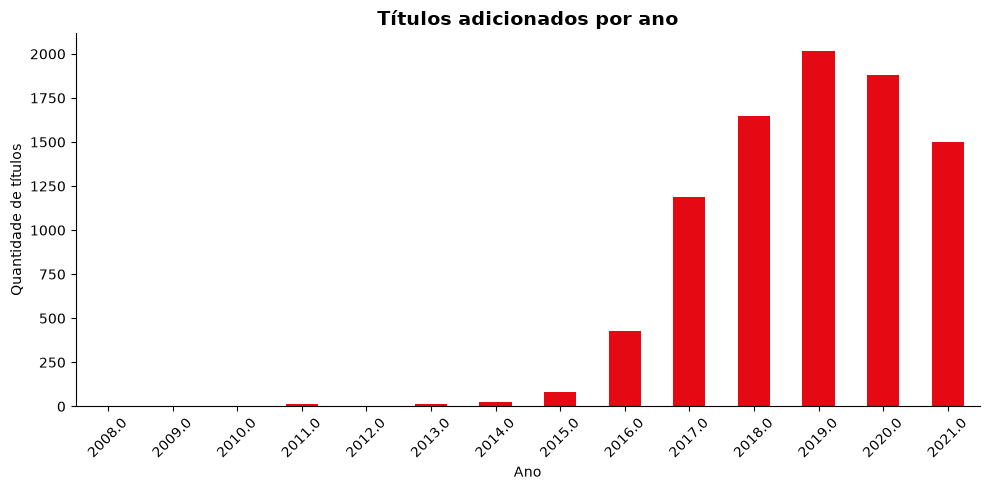

In [39]:
df["ano_adicionado"] = df["date_added"].dt.year
titulos_por_ano = df.groupby("ano_adicionado")["show_id"].count()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))          # tamanho da figura

titulos_por_ano.plot(kind="bar", ax=ax, color="#E50914")  # cor (vermelho Netflix, por ex.)

ax.set_title("Títulos adicionados por ano", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de títulos")

ax.spines["top"].set_visible(False)               # remove bordas desnecessárias
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)                             # rótulos do eixo X inclinados (evita sobreposição)
plt.tight_layout()                                    # ajusta margens automaticamente pra nada cortar

plt.show()
#Responde: em que período a Netflix mais expandiu o catálogo.


In [40]:
df["defasagem_anos"] = df["ano_adicionado"] - df["release_year"]
df["defasagem_anos"].describe()

#Responde: a Netflix adiciona majoritariamente conteúdo recém lançado ou catálogo antigo ?

count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: defasagem_anos, dtype: float64

In [41]:
df[df["defasagem_anos"] < 0][["title", "release_year", "date_added", "ano_adicionado"]]

,title,release_year,date_added,ano_adicionado
1551,Hilda,2021,2020-12-14,2020.0
1696,Polly Pocket,2021,2020-11-15,2020.0
2920,Love Is Blind,2021,2020-02-13,2020.0
3168,Fuller House,2020,2019-12-06,2019.0
3287,Maradona in Mexico,2020,2019-11-13,2019.0
3369,BoJack Horseman,2020,2019-10-25,2019.0
3433,The Hook Up Plan,2020,2019-10-11,2019.0
4844,Unbreakable Kimmy Schmidt,2019,2018-05-30,2018.0
4845,Arrested Development,2019,2018-05-29,2018.0
5394,Hans Teeuwen: Real Rancour,2018,2017-07-01,2017.0


### Por que tem defasagem negativa?

Reparei que um grupo de títulos (tipo o *Hilda*) tem defasagem negativa —
ou seja, a data que entrou no catálogo é *antes* do ano de lançamento
oficial. Fui investigar e não é erro nos dados: acontece porque
`release_year` é o ano "oficial" de lançamento dado pela produtora, e não
necessariamente a data real de estreia. É comum título que estreia em
dezembro já sair rotulado com o ano seguinte.

Decidi manter essas linhas — não faz sentido apagar algo que não é erro,
é só assim que a indústria classifica o ano de lançamento mesmo. Por
causa disso, prefiro usar a **mediana** (1 ano) em vez da média pra falar
da defasagem, já que esses casos puxam a média pra baixo sem representar
o padrão real do catálogo.

In [42]:
paises["country"].value_counts().head(10)
#Responde: quais países concentram a produção do catálogo.

country
United States     3211
India             1008
Não informado      831
United Kingdom     628
 United States     479
Canada             271
Japan              259
France             212
South Korea        211
 France            181
Name: count, dtype: int64

In [43]:
generos = df.assign(listed_in=df["listed_in"].str.split(",")).explode("listed_in")
generos["listed_in"].value_counts().head(10)

#Responde: quais gêneros dominam informação direta para decisõesde curadoria/aquisição de conteúdo.


listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64

In [44]:
df["rating"].value_counts()

#Responde: o público-alvo predominante do catálogo

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [45]:
df["duracao_minutos"].describe()
df["temporadas"].describe()

#Responde: qual é a duração “padrão” de um filme no catálogo e quantas temporadas uma série típica tem.

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: temporadas, dtype: float64

## SQL Básico com SQLite

In [52]:
import sqlite3

conn = sqlite3.connect("../data/netflix.db")
df.to_sql("titulos", conn, if_exists="replace", index=False)


8807

In [54]:
import pandas as pd
pd.read_sql("SELECT * FROM titulos LIMIT 5", conn)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duracao_minutos,temporadas,ano_adicionado,defasagem_anos
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Não informado,United States,2021-09-25 00:00:00,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN,2021.0,1.0
1,s2,TV Show,Blood & Water,Não informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0,2021.0,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Não informado,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0,2021.0,0.0
3,s4,TV Show,Jailbirds New Orleans,Não informado,Não informado,Não informado,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0,2021.0,0.0
4,s5,TV Show,Kota Factory,Não informado,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0,2021.0,0.0


In [55]:
#Total de títulos

pd.read_sql("SELECT COUNT(*) FROM titulos;", conn)

,COUNT(*)
0,8807


In [56]:
pd.read_sql("SELECT DISTINCT type FROM titulos", conn)


,type
0,Movie
1,TV Show


In [57]:
pd.read_sql("select type from titulos WHERE TYPE = 'Movie'", conn)

,type
0,Movie
1,Movie
2,Movie
3,Movie
4,Movie
...,...
6126,Movie
6127,Movie
6128,Movie
6129,Movie


In [66]:
# Filmes x Series
pd.read_sql("""SELECT type, COUNT(*) AS total 
    FROM titulos 
    GROUP BY type;""", conn)

,type,total
0,Movie,6131
1,TV Show,2676


In [69]:
# Top 10 anos com mais lançamentos
pd.read_sql("""
    SELECT release_year, COUNT(*) AS total
    FROM titulos
    GROUP BY release_year
    ORDER BY total DESC
    LIMIT 10;
""", conn)

,release_year,total
0,2018,1147
1,2017,1032
2,2019,1030
3,2020,953
4,2016,902
5,2021,592
6,2015,560
7,2014,352
8,2013,288
9,2012,237


In [70]:
# Títulos por classificação etária

pd.read_sql("""
    SELECT rating, COUNT(*) AS total
    FROM titulos
    GROUP BY rating
    ORDER BY total DESC;
""", conn)

,rating,total
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


In [71]:
# Duração média de filmes

pd.read_sql("""
    SELECT AVG(duracao_minutos) AS duracao_media
    FROM titulos
    WHERE type = 'Movie';
""", conn)

,duracao_media
0,99.577187


In [ ]:
# Filmes lançados depois de 2015, ordenados por ano


pd.read_sql("""
    SELECT title, release_year
    FROM titulos
    WHERE type = 'Movie' AND release_year > 2015
    ORDER BY release_year DESC
    LIMIT 20;
""", conn)

,title,release_year
0,My Little Pony: A New Generation,2021
1,The Starling,2021
2,Je Suis Karl,2021
3,Confessions of an Invisible Girl,2021
4,Intrusion,2021
5,Go! Go! Cory Carson: Chrissy Takes the Wheel,2021
6,Ankahi Kahaniya,2021
7,The Father Who Moves Mountains,2021
8,The Stronghold,2021
9,My Heroes Were Cowboys,2021


In [73]:
# Séries com mais de 5 temporadas

pd.read_sql("""
    SELECT title, temporadas
    FROM titulos
    WHERE type = 'TV Show' AND temporadas > 5
    ORDER BY temporadas DESC;
""", conn)

,title,temporadas
0,Grey's Anatomy,17.0
1,Supernatural,15.0
2,NCIS,15.0
3,Heartland,13.0
4,COMEDIANS of the world,13.0
...,...,...
94,West Coast Customs,6.0
95,Father Brown,6.0
96,Gossip Girl,6.0
97,Republic of Doyle,6.0


In [74]:
# Quantos títulos têm diretor não informado


pd.read_sql("""
    SELECT COUNT(*) AS sem_diretor
    FROM titulos
    WHERE director = 'Não informado';
""", conn)

,sem_diretor
0,2634
